<a href="https://colab.research.google.com/github/miffylim2308/ADALL_github/blob/main/Test_Grab_Transbport.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Section 1: Upload and Read Dataset**

In [1]:
import pandas as pd
# Example: Replace this with the raw URL of your GitHub file
github_raw_url = 'https://raw.githubusercontent.com/miffylim2308/ADALL_github/refs/heads/main/synthetic_grab_transport_v3.csv'
try:
    df = pd.read_csv(github_raw_url)
    print("Successfully loaded data from GitHub!")
    display(df.head())
except Exception as e:
    print(f"Error loading data: {e}")
    print("Please ensure the URL is correct and the file format is compatible with `pd.read_csv`.")


Successfully loaded data from GitHub!


,booking_id,booking_datetime,booking_hour,day_of_week,month,is_weekend,is_peak_hour,is_late_night,public_holiday,pickup_zone,...,traffic_level,surge_multiplier,surge_changed_after_booking,promo_applied,promo_discount_sgd,estimated_fare_sgd,app_version,network_quality,customer_cancelled,cancel_reason
0,BK2026003888,2026-02-05 09:06:53,9,Thursday,2,0,1,0,0,Marina Bay,...,High,1.71,1,1,2,8.16,Current,Average,1,Driver took too long
1,BK2026006688,2026-03-02 20:37:37,20,Monday,3,0,1,0,0,Punggol,...,Low,1.36,0,0,0,13.47,One version behind,Poor,1,Found alternative transport
2,BK2026008916,2026-03-22 06:33:47,6,Sunday,3,1,0,0,0,Queenstown,...,High,1.00,0,0,0,20.45,Outdated,Good,0,Not Cancelled
3,BK2026017566,2026-06-08 02:38:19,2,Monday,6,0,0,1,0,Clementi,...,Medium,1.20,0,0,0,11.22,One version behind,Good,0,Not Cancelled
4,BK2026015911,2026-05-24 05:51:21,5,Sunday,5,1,0,1,0,Marina Bay,...,Medium,1.00,0,0,0,7.80,Current,Good,0,Not Cancelled


In [2]:
#df.describe()
df.describe()

,booking_hour,month,is_weekend,is_peak_hour,is_late_night,public_holiday,airport_trip,cbd_trip,distance_km,estimated_trip_duration_min,...,driver_distance_to_pickup_km,driver_eta_min,eta_change_min,is_raining,surge_multiplier,surge_changed_after_booking,promo_applied,promo_discount_sgd,estimated_fare_sgd,customer_cancelled
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,...,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,11.572400,3.501300,0.287500,0.296450,0.284900,0.032650,0.165350,0.321900,10.970966,21.730420,...,2.106427,6.339315,1.304590,0.19395,1.150835,0.094250,0.232050,1.010000,19.491597,0.220000
std,6.882356,1.698836,0.452608,0.456703,0.451378,0.177723,0.371505,0.467217,6.499934,14.117664,...,1.392898,3.709736,2.462881,0.39540,0.212908,0.292184,0.422151,2.202826,10.873980,0.414257
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.010000,4.000000,...,0.200000,1.400000,-5.000000,0.00000,1.000000,0.000000,0.000000,0.000000,4.000000,0.000000
25%,6.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.940000,11.100000,...,1.040000,3.600000,-0.400000,0.00000,1.000000,0.000000,0.000000,0.000000,11.500000,0.000000
50%,12.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.640000,18.500000,...,1.840000,5.500000,1.200000,0.00000,1.000000,0.000000,0.000000,0.000000,17.150000,0.000000
75%,18.000000,5.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,14.730000,29.000000,...,2.880000,8.100000,2.900000,0.00000,1.260000,0.000000,0.000000,0.000000,25.040000,0.000000
max,23.000000,6.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,38.000000,95.000000,...,9.500000,30.000000,11.700000,1.00000,2.080000,1.000000,1.000000,10.000000,98.770000,1.000000


#**Section 2: Define Target and Remove Leakage Columns**

In [3]:
target = "customer_cancelled"

drop_cols = [
    "booking_id",
    "booking_datetime",
    "cancel_reason"   # leakage: only known after cancellation
]

X = df.drop(columns=[target] + drop_cols)
y = df[target]

print(X.shape)
print(y.value_counts(normalize=True))

(20000, 46)
customer_cancelled
0    0.78
1    0.22
Name: proportion, dtype: float64


#**Section 3: Correlation for Numeric Variables**

In [4]:
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns

corr_df = df[numeric_cols.tolist() + [target]].corr()[target] \
    .drop(target) \
    .sort_values(key=abs, ascending=False) \
    .reset_index()

corr_df.columns = ["Feature", "Correlation with customer_cancelled"]

corr_df.head(15)

,Feature,Correlation with customer_cancelled
0,surge_multiplier,0.681969
1,driver_eta_min,0.637897
2,is_peak_hour,0.548839
3,supply_demand_ratio,-0.526886
4,drivers_declined_before_accept,0.515614
5,driver_distance_to_pickup_km,0.472420
6,booking_demand_zone,0.455134
7,active_driver_supply_zone,-0.429970
8,driver_acceptance_time_sec,0.371512
9,eta_change_min,0.329588


#**Section 4. Prepare data for machine learning**

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

categorical_cols = X.select_dtypes(include=["object"]).columns
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

#**Section 5. Logistic Regression coefficients**

In [6]:
from sklearn.linear_model import LogisticRegression

log_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

log_model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['booking_hour', 'month', 'is_weekend', 'is_peak_hour', 'is_late_night',
       'public_holiday', 'airport_trip', 'cbd_trip', 'distance_km',
       'estimated_trip_duration_min', 'customer_tenure_days',
       'rides_last_7_days', 'rides_last_30_days', 'customer_cancel_rate_90d',
       'previous_cu...
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['day_of_week', 'pickup_zone', 'pickup_zone_type', 'dropoff_zone',
       'dropoff_zone_type', 'vehicle_type', 'payment_method',
       'customer_segment', 'loyalty_tier', 'weather', 'traffic_level',
       'app_version', 'network_quality'],
      dtype='object'))])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [ ]:
import numpy as np

feature_names = log_model.named_steps["preprocess"].get_feature_names_out()
coefficients = log_model.named_steps["model"].coef_[0]

log_coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Abs_Coefficient": np.abs(coefficients)
}).sort_values("Abs_Coefficient", ascending=False)

log_coef_df.head(20)

,Feature,Coefficient,Abs_Coefficient
25,num__driver_eta_min,3.236563,3.236563
28,num__surge_multiplier,1.800472,1.800472
96,cat__customer_segment_New,1.528951,1.528951
22,num__drivers_declined_before_accept,1.328002,1.328002
26,num__eta_change_min,1.300449,1.300449
95,cat__customer_segment_High Value,-1.209802,1.209802
110,cat__traffic_level_Severe,1.096197,1.096197
98,cat__customer_segment_Regular,-0.888023,0.888023
30,num__promo_applied,-0.855228,0.855228
111,cat__app_version_Current,-0.749813,0.749813


#**Section 6. Random Forest feature importance**

In [7]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['booking_hour', 'month', 'is_weekend', 'is_peak_hour', 'is_late_night',
       'public_holiday', 'airport_trip', 'cbd_trip', 'distance_km',
       'estimated_trip_duration_min', 'customer_tenure_days',
       'rides_last_7_days', 'rides_last_30_days', 'customer_cancel_rate_90d',
       'previous_cu...
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['day_of_week', 'pickup_zone', 'pickup_zone_type', 'dropoff_zone',
       'dropoff_zone_type', 'vehicle_type', 'payment_method',
       'customer_segment', 'loyalty_tier', 'weather', 'traffic_level',
       'app_version', 'network_quality'],
      dtype='object'))])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=10,
                                        n_estimators=300, n_jobs=-1,
                                        random_state=42))])

In [8]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['booking_hour', 'month', 'is_weekend', 'is_peak_hour', 'is_late_night',
       'public_holiday', 'airport_trip', 'cbd_trip', 'distance_km',
       'estimated_trip_duration_min', 'customer_tenure_days',
       'rides_last_7_days', 'rides_last_30_days', 'customer_cancel_rate_90d',
       'previous_cu...
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['day_of_week', 'pickup_zone', 'pickup_zone_type', 'dropoff_zone',
       'dropoff_zone_type', 'vehicle_type', 'payment_method',
       'customer_segment', 'loyalty_tier', 'weather', 'traffic_level',
       'app_version', 'network_quality'],
      dtype='object'))])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=10,
                                        n_estimators=300, n_jobs=-1,
                                        random_state=42))])

#**Section 7. SHAP values**

In [ ]:
!pip install shap -q

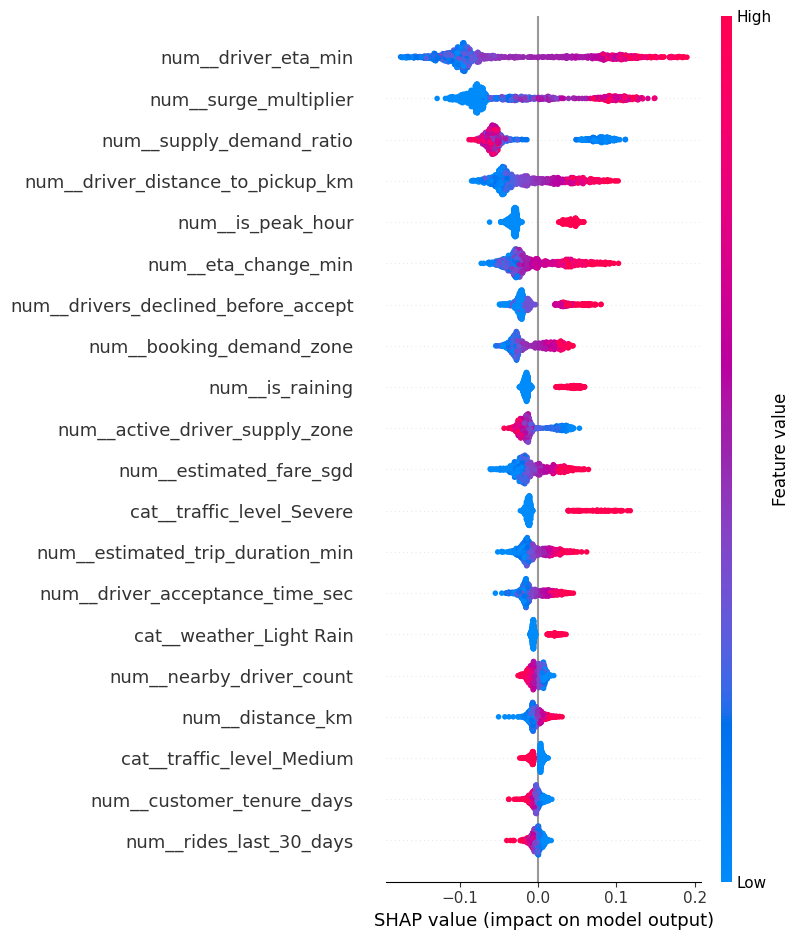

In [9]:
import shap

# Transform training and test data
X_train_transformed = rf_model.named_steps["preprocess"].transform(X_train)
X_test_transformed = rf_model.named_steps["preprocess"].transform(X_test)

# Convert sparse matrix to dense if needed
X_test_dense = X_test_transformed.toarray() if hasattr(X_test_transformed, "toarray") else X_test_transformed
import shap

# Transform test data
X_test_transformed = rf_model.named_steps["preprocess"].transform(X_test)

# Convert sparse matrix to dense if needed
X_test_dense = (
    X_test_transformed.toarray()
    if hasattr(X_test_transformed, "toarray")
    else X_test_transformed
)

# Get transformed feature names
feature_names = rf_model.named_steps["preprocess"].get_feature_names_out()

# Use a sample
sample_size = 1000
X_shap = X_test_dense[:sample_size]

# Convert X_shap back to DataFrame with feature names
X_shap_df = pd.DataFrame(X_shap, columns=feature_names)

# SHAP
explainer = shap.TreeExplainer(rf_model.named_steps["model"])
shap_values = explainer.shap_values(X_shap)

# For binary classification: class 1 = customer cancelled
shap_cancelled = shap_values[:, :, 1]

shap.summary_plot(
    shap_cancelled,
    X_shap_df
)
# Use a sample to keep SHAP fast
sample_size = 1000
X_shap = X_test_dense[:sample_size]

explainer = shap.TreeExplainer(rf_model.named_steps["model"])
shap_values = explainer.shap_values(X_shap)

In [ ]:
#Checking the shape of shap values
print("X_shap shape:", X_shap.shape)
print("Type of shap_values:", type(shap_values))

if isinstance(shap_values, list):
    print("shap_values[0] shape:", shap_values[0].shape)
    print("shap_values[1] shape:", shap_values[1].shape)
else:
    print("shap_values shape:", shap_values.shape)
print(type(X_shap))
print(type(X_shap_df))
print(X_shap.shape)
print(X_shap_df.shape)

X_shap shape: (1000, 117)
Type of shap_values: <class 'numpy.ndarray'>
shap_values shape: (1000, 117, 2)
<class 'numpy.ndarray'>
<class 'pandas.core.frame.DataFrame'>
(1000, 117)
(1000, 117)


In [10]:
print("rf_importance_df" in globals())

False


#**Section 8. Create final comparison table**

In [ ]:
import pandas as pd

# Get transformed feature names after preprocessing
feature_names = rf_model.named_steps["preprocess"].get_feature_names_out()

# Get Random Forest feature importances
rf_importances = rf_model.named_steps["model"].feature_importances_

# Create DataFrame
rf_importance_df = (
    pd.DataFrame({
        "Feature": feature_names,
        "RF_Importance": rf_importances
    })
    .sort_values("RF_Importance", ascending=False)
    .reset_index(drop=True)
)

display(rf_importance_df.head(15))

,Feature,RF_Importance
0,num__driver_eta_min,0.167078
1,num__surge_multiplier,0.131994
2,num__supply_demand_ratio,0.116367
3,num__driver_distance_to_pickup_km,0.068291
4,num__is_peak_hour,0.062626
5,num__active_driver_supply_zone,0.051831
6,num__booking_demand_zone,0.046655
7,num__eta_change_min,0.038297
8,num__drivers_declined_before_accept,0.037332
9,cat__traffic_level_Severe,0.026966


In [ ]:
top_corr = corr_df.head(15)
top_log = log_coef_df.head(15)
top_rf = rf_importance_df.head(15)

print("Top Numeric Correlations")
display(top_corr)

print("Top Logistic Regression Coefficients")
display(top_log)

print("Top Random Forest Importances")
display(top_rf)

Top Numeric Correlations


,Feature,Correlation with customer_cancelled
0,surge_multiplier,0.681969
1,driver_eta_min,0.637897
2,is_peak_hour,0.548839
3,supply_demand_ratio,-0.526886
4,drivers_declined_before_accept,0.515614
5,driver_distance_to_pickup_km,0.472420
6,booking_demand_zone,0.455134
7,active_driver_supply_zone,-0.429970
8,driver_acceptance_time_sec,0.371512
9,eta_change_min,0.329588


Top Logistic Regression Coefficients


,Feature,Coefficient,Abs_Coefficient
25,num__driver_eta_min,3.236563,3.236563
28,num__surge_multiplier,1.800472,1.800472
96,cat__customer_segment_New,1.528951,1.528951
22,num__drivers_declined_before_accept,1.328002,1.328002
26,num__eta_change_min,1.300449,1.300449
95,cat__customer_segment_High Value,-1.209802,1.209802
110,cat__traffic_level_Severe,1.096197,1.096197
98,cat__customer_segment_Regular,-0.888023,0.888023
30,num__promo_applied,-0.855228,0.855228
111,cat__app_version_Current,-0.749813,0.749813


Top Random Forest Importances


,Feature,RF_Importance
0,num__driver_eta_min,0.167078
1,num__surge_multiplier,0.131994
2,num__supply_demand_ratio,0.116367
3,num__driver_distance_to_pickup_km,0.068291
4,num__is_peak_hour,0.062626
5,num__active_driver_supply_zone,0.051831
6,num__booking_demand_zone,0.046655
7,num__eta_change_min,0.038297
8,num__drivers_declined_before_accept,0.037332
9,cat__traffic_level_Severe,0.026966
